# Cannon dynamics

In [7]:
# state: x, y, vx, vy
# control: init vx, vy
import numpy as np
from scipy.integrate import solve_ivp

class CannonSimulator:
    c:float
    g:float = 9.8
    def __init__(self, c):
        self.c = c
    
    def dynamics(self, state, control, dt):
        x, y, vx, vy = state
        
        dx = vx
        dy = vy
        v = np.sqrt(vx**2 + vy**2)
        dvx = -self.c * v * vx
        dvy = -self.c * v * vy - self.g
        return [dx, dy, dvx, dvy]

    def step(self, state, control, dt):
        x, y, vx, vy = state
        return solve_ivp(lambda t, s: self.dynamics(s, control, dt), [0, dt], state).y[:, -1]


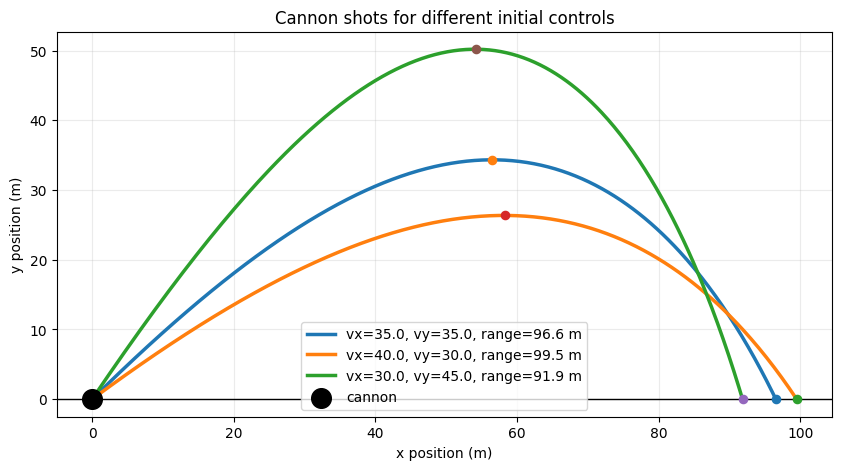

In [8]:
import matplotlib.pyplot as plt

def simulate_shot(control, c=0.01, dt=0.02, max_time=20.0):
    sim = CannonSimulator(c=c)
    control = np.asarray(control, dtype=float)
    state = np.array([0.0, 0.0, control[0], control[1]])
    trajectory = [state.copy()]

    for _ in range(int(max_time / dt)):
        prev_state = state.copy()
        state = sim.step(state, control, dt)

        if state[1] < 0:
            # The last integration step crossed the ground, so interpolate between
            # the previous positive-y state and the current negative-y state.
            alpha = prev_state[1] / (prev_state[1] - state[1])
            landing_state = prev_state + alpha * (state - prev_state)
            trajectory.append(landing_state)
            break

        trajectory.append(state.copy())

    return np.array(trajectory)


def plot_shot(control, c=0.01, dt=0.02, max_time=20.0, ax=None, label=None):
    trajectory = simulate_shot(control, c=c, dt=dt, max_time=max_time)
    x = trajectory[:, 0]
    y = trajectory[:, 1]
    apex_index = np.argmax(y)
    range_x = x[-1]
    max_height = y[apex_index]

    if ax is None:
        _, ax = plt.subplots(figsize=(10, 5))

    if label is None:
        label = f"vx={control[0]:.1f}, vy={control[1]:.1f}, range={range_x:.1f} m"

    ax.plot(x, y, linewidth=2.5, label=label)
    ax.scatter([range_x], [0], s=35, zorder=5)
    ax.scatter([x[apex_index]], [max_height], s=35, zorder=5)
    return trajectory


controls = [
    np.array([35.0, 35.0]),
    np.array([40.0, 30.0]),
    np.array([30.0, 45.0]),
]

fig, ax = plt.subplots(figsize=(10, 5))
trajectories = [plot_shot(control, ax=ax) for control in controls]

ax.axhline(0, color="black", linewidth=1)
ax.scatter([0], [0], s=200, color="black", zorder=5, label="cannon")
ax.set_title("Cannon shots for different initial controls")
ax.set_xlabel("x position (m)")
ax.set_ylabel("y position (m)")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()


# Single shooting
Only change init state, use simulation to optimize.

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 1261.8033635356517
           x: [ 3.964e+01  3.086e+01]
         nit: 8
         jac: [ 3.964e+01  3.086e+01]
        nfev: 24
        njev: 8
 multipliers: [ 2.662e+01]
best control: [39.64044814 30.85841211]
initial energy: 1261.8033635356517
range error: -1.9297061726319953e-09


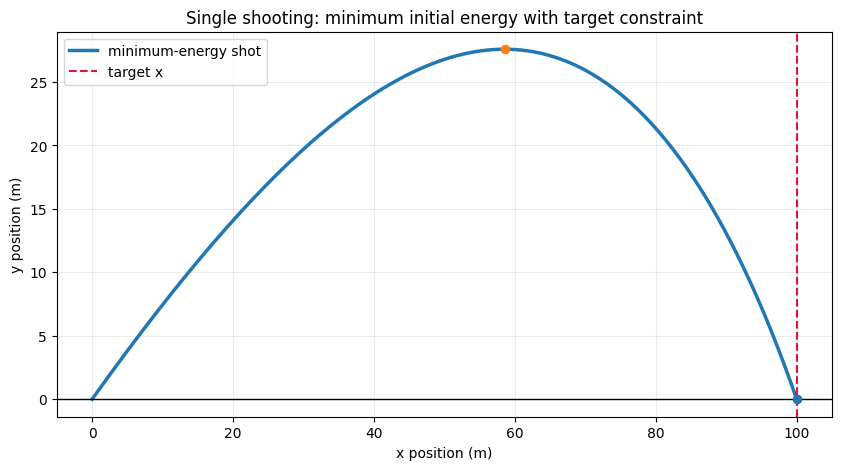

In [15]:
from scipy.optimize import minimize

# Single shooting with minimum initial energy:
# 1. Decision variable z = [vx0, vy0].
# 2. Objective: minimize initial kinetic energy.
# 3. Constraint: after one simulated shot, the landing x should match target_x.
#
# Why not just use target error + energy in one loss?
# That is a penalty method. It is useful, but the weight decides the trade-off.
# Here, SLSQP lets us say the real goal more directly:
# "hit the target, and among those shots, use the least initial energy."

target_x = 100.0

target_y = 0.0  # landing interpolation already makes final y close to 0
mass = 1.0      # use 1 kg for now, so energy mainly compares control size

initial_guess = np.array([45.0, 40.0])
bounds = [
    (0.0, 100.0),  # vx0 lower/upper bound
    (0.0, 100.0),  # vy0 lower/upper bound
]


def initial_energy_objective(z):
    """Objective function: minimize initial kinetic energy.

    Your task:
    - Read z as [vx0, vy0].
    - Use E = 1/2 * m * (vx0^2 + vy0^2).
    - Return one scalar energy value.
    """
    control = np.asarray(z, dtype=float)

    # TODO: unpack vx0 and vy0 from control.
    # TODO: compute and return initial kinetic energy.
    vx0, vy0 = control
    energy = 0.5 * mass * (vx0**2 + vy0**2)
    return energy


def target_range_constraint(z):
    """Equality constraint for SLSQP.

    SLSQP treats this as satisfied when the returned value is close to 0.
    For this problem, return: landing_x - target_x.
    """
    control = np.asarray(z, dtype=float)
    trajectory = simulate_shot(control, c=0.01, dt=0.02, max_time=20.0)
    final_state = trajectory[-1]

    # TODO: extract landing_x from final_state.
    # Hint: state format is [x, y, vx, vy].
    landing_x = final_state[0]

    # TODO: return landing_x - target_x.
    return landing_x - target_x


constraints = [
    {"type": "eq", "fun": target_range_constraint},
]


# After you finish the two TODO functions, uncomment this block:
result = minimize(
    initial_energy_objective,
    initial_guess,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
)

best_control = result.x
print(result)
print("best control:", best_control)
print("initial energy:", initial_energy_objective(best_control))
print("range error:", target_range_constraint(best_control))

fig, ax = plt.subplots(figsize=(10, 5))
best_trajectory = plot_shot(best_control, ax=ax, label="minimum-energy shot")
ax.axvline(target_x, color="crimson", linestyle="--", label="target x")
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Single shooting: minimum initial energy with target constraint")
ax.set_xlabel("x position (m)")
ax.set_ylabel("y position (m)")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()


# Multiple Shooting
Split to multple segments, and use defects to constrain the path

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 1261.776752270689
           x: [ 3.966e+01  3.084e+01 ...  1.219e+01 -1.951e+01]
         nit: 11
         jac: [ 3.966e+01  3.084e+01 ...  0.000e+00  0.000e+00]
        nfev: 308
        njev: 11
 multipliers: [ 2.664e+01  1.665e+01 ...  2.664e+01  1.665e+01]
best control: [39.65542733 30.83829742]
best final time: 4.692118307948232
initial energy: 1261.776752270689
constraint residual norm: 3.94495217713449e-09


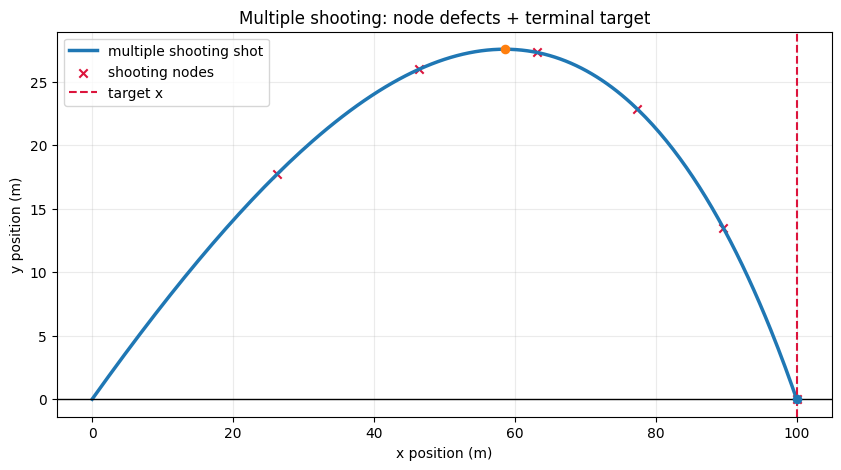

In [16]:
# Multiple shooting with minimum initial energy:
#
# Single shooting optimized only z = [vx0, vy0].
# Multiple shooting also introduces intermediate states as decision variables.
#
# Decision variable layout for this tutorial:
# z = [vx0, vy0, final_time, state_1, state_2, ..., state_N]
# where each state_k = [x_k, y_k, vx_k, vy_k].
#
# Defect constraint for each segment:
# integrate(state_{k-1}, segment_dt) - state_k = 0
#
# Terminal constraint:
# final node should hit [target_x, target_y].

n_segments = 6
state_dim = 4

control_guess = np.array([45.0, 40.0])
final_time_guess = 5.0

# This simple guess is intentionally rough. A nicer next step is to sample
# nodes from simulate_shot(control_guess), but try the plain version first.
node_state_guess = np.zeros((n_segments, state_dim))
# concatenate control, final_time, and flattened node states into one long vector for optimization
multiple_shooting_initial_guess = np.concatenate([
    control_guess,
    np.array([final_time_guess]),
    node_state_guess.ravel(), # ravel() flattens the node states into a long vector
])

multiple_shooting_bounds = (
    [(1.0, 100.0), (1.0, 100.0)]  # vx0, vy0
    + [(0.5, 20.0)]                # final_time
    + [(None, None)] * (n_segments * state_dim)
)

# build sim
sim = CannonSimulator(c=0.01)


def unpack_multiple_shooting_z(z):
    """Split the long optimizer vector into useful pieces.

    Your task:
    - Extract control = [vx0, vy0].
    - Extract final_time.
    - Reshape the remaining values into node_states with shape
      (n_segments, state_dim).
    """
    z = np.asarray(z, dtype=float)

    # TODO: unpack z into control, final_time, and node_states.
    control = z[:2]
    final_time = z[2]
    node_states = z[3:].reshape((n_segments, state_dim))
    return control, final_time, node_states


def multiple_shooting_energy_objective(z):
    """Same objective as single shooting: minimize initial kinetic energy."""
    control, final_time, node_states = unpack_multiple_shooting_z(z)

    # TODO: compute 1/2 * mass * (vx0^2 + vy0^2).
    # Hint: final_time and node_states are not part of the energy objective.
    control, _, _ = unpack_multiple_shooting_z(z)
    vx0, vy0 = control
    return 0.5 * mass * (vx0**2 + vy0**2)


def multiple_shooting_defects_and_terminal(z):
    """Equality constraints for multiple shooting.

    Return one flat array. SLSQP will try to make every entry equal to 0.
    """
    control, final_time, node_states = unpack_multiple_shooting_z(z)
    segment_dt = final_time / n_segments
    constraints = []

    segment_start = np.array([0.0, 0.0, control[0], control[1]])

    for k in range(n_segments):
        node_end = node_states[k]

        # integrate one segment from segment_start for segment_dt.
        # Hint: sim.step(segment_start, control, segment_dt) gives the predicted end.
        predicted_end = sim.step(segment_start, control, segment_dt)

        # append the defect predicted_end - node_end to constraints.
        # Hint: constraints.extend(defect) is useful because defect has 4 values.
        defect = predicted_end - node_end
        constraints.extend(defect)

        # move to the next segment by setting segment_start = node_end.
        segment_start = node_end

    final_state = node_states[-1]
    final_x, final_y = final_state[0], final_state[1]

    # append terminal constraints:
    # final_x - target_x = 0
    # final_y - target_y = 0
    constraints.extend([final_x - target_x, final_y - target_y])

    # return np.asarray(constraints)
    return np.asarray(constraints)


multiple_shooting_constraints = [
    {"type": "eq", "fun": multiple_shooting_defects_and_terminal},
]


# After you finish the TODOs, uncomment this block:
result_ms = minimize(
    multiple_shooting_energy_objective,
    multiple_shooting_initial_guess,
    method="SLSQP",
    bounds=multiple_shooting_bounds,
    constraints=multiple_shooting_constraints,
    options={"maxiter": 200},
)

best_control_ms, best_final_time_ms, best_nodes_ms = unpack_multiple_shooting_z(result_ms.x)
print(result_ms)
print("best control:", best_control_ms)
print("best final time:", best_final_time_ms)
print("initial energy:", multiple_shooting_energy_objective(result_ms.x))
print("constraint residual norm:", np.linalg.norm(multiple_shooting_defects_and_terminal(result_ms.x)))

fig, ax = plt.subplots(figsize=(10, 5))
plot_shot(best_control_ms, ax=ax, label="multiple shooting shot")
ax.scatter(best_nodes_ms[:, 0], best_nodes_ms[:, 1], marker="x", color="crimson", label="shooting nodes")
ax.axvline(target_x, color="crimson", linestyle="--", label="target x")
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Multiple shooting: node defects + terminal target")
ax.set_xlabel("x position (m)")
ax.set_ylabel("y position (m)")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()


# Trust-constr: single shooting
Use the same single-shooting objective and target constraint, but wrap the constraint with `NonlinearConstraint` for `method="trust-constr"`.

/Users/liudongxu/opt/miniconda3/envs/aviation/lib/python3.13/site-packages/scipy/optimize/_differentiable_functions.py:385: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)
/Users/liudongxu/opt/miniconda3/envs/aviation/lib/python3.13/site-packages/scipy/optimize/_differentiable_functions.py:737: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(delta_x, delta_g)


`xtol` termination condition is satisfied.
Number of iterations: 77, function evaluations: 303, CG iterations: 65, optimality: 4.36e-06, constraint violation: 1.42e-14, execution time:  4.9 s.
           message: `xtol` termination condition is satisfied.
           success: True
            status: 2
               fun: 1261.8033635791755
                 x: [ 3.964e+01  3.086e+01]
               nit: 77
              nfev: 303
              njev: 101
              nhev: 0
          cg_niter: 65
      cg_stop_cond: 1
              grad: [ 3.964e+01  3.086e+01]
   lagrangian_grad: [-3.391e-06  4.356e-06]
            constr: [array([-1.421e-14]), array([ 3.964e+01,  3.086e+01])]
               jac: [array([[ 1.489e+00,  1.159e+00]]), array([[ 1.000e+00,  0.000e+00],
                           [ 0.000e+00,  1.000e+00]])]
       constr_nfev: [303, 0]
       constr_njev: [0, 0]
       constr_nhev: [0, 0]
                 v: [array([-2.662e+01]), array([ 3.183e-09, -5.837e-09])]
           

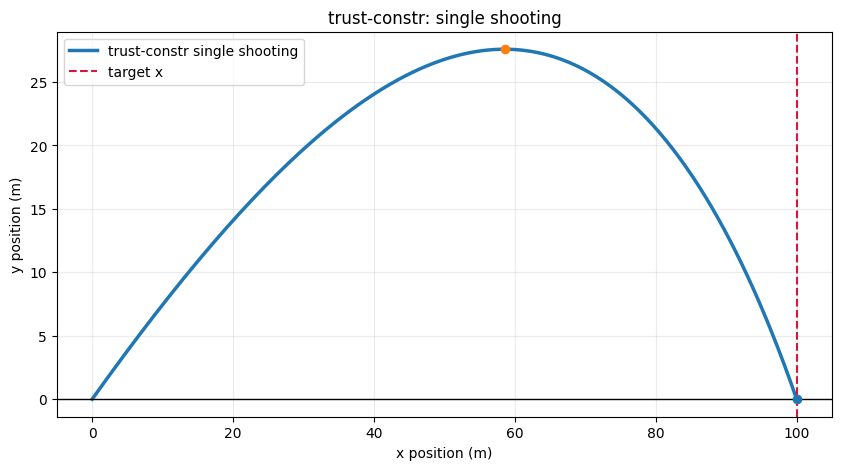

In [17]:
from scipy.optimize import Bounds, NonlinearConstraint

# Reuse what you already wrote above:
# - initial_energy_objective(z)
# - target_range_constraint(z)
# - initial_guess
# - plot_shot(best_control, ...)
#
# The main trust-constr difference is how constraints and bounds are packaged.
# SLSQP accepted dict constraints; trust-constr prefers NonlinearConstraint.

single_trust_bounds = Bounds(
    lb=[1.0, 1.0],
    ub=[100.0, 100.0],
)

# lb and ub bound the value returned by target_range_constraint.
# Since target_range_constraint returns landing_x - target_x,
# setting lb=ub=0 means the allowed residual is exactly 0: hit the target.
single_trust_target_constraint = NonlinearConstraint(
    fun=target_range_constraint,
    lb=0.0,
    ub=0.0,
)

# Teaching notes:
# - objective: still minimize initial kinetic energy.
# - constraint: still landing_x - target_x = 0.
# - simulator: still hidden inside target_range_constraint via simulate_shot(...).
# - gradients: if you do not provide jac/hess, SciPy estimates derivatives numerically.
#
# Your task:
# 1. Make sure initial_energy_objective and target_range_constraint work first.
# 2. Uncomment the block below.
# 3. Compare result_trust_single.x with the SLSQP result.x above.

result_trust_single = minimize(
    initial_energy_objective,
    initial_guess,
    method="trust-constr",
    bounds=single_trust_bounds,
    constraints=[single_trust_target_constraint],
    options={"verbose": 1},
)

best_control_trust_single = result_trust_single.x
print(result_trust_single)
print("best control:", best_control_trust_single)
print("initial energy:", initial_energy_objective(best_control_trust_single))
print("range error:", target_range_constraint(best_control_trust_single))

fig, ax = plt.subplots(figsize=(10, 5))
plot_shot(best_control_trust_single, ax=ax, label="trust-constr single shooting")
ax.axvline(target_x, color="crimson", linestyle="--", label="target x")
ax.axhline(0, color="black", linewidth=1)
ax.set_title("trust-constr: single shooting")
ax.set_xlabel("x position (m)")
ax.set_ylabel("y position (m)")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()


# Trust-constr: multiple shooting
Reuse the multiple-shooting objective and the vector-valued defect constraint; `NonlinearConstraint` can handle a whole residual vector.

| niter |f evals|CG iter|  obj func   |tr radius |   opt    |  c viol  |
|-------|-------|-------|-------------|----------|----------|----------|
|   1   |  28   |   0   | +1.8125e+03 | 1.00e+00 | 4.08e+00 | 1.00e+02 |
|   2   |  56   |   1   | +1.7975e+03 | 7.00e+00 | 8.36e+00 | 9.98e+01 |
|   3   |  84   |   2   | +1.6870e+03 | 4.01e+01 | 7.56e+00 | 9.64e+01 |
|   4   |  112  |   3   | +1.1560e+03 | 2.31e+02 | 2.66e+00 | 7.76e+01 |
|   5   |  140  |   4   | +9.3046e+02 | 7.22e+02 | 7.09e+00 | 2.60e+01 |
|   6   |  168  |   5   | +1.3381e+03 | 7.22e+02 | 1.03e+01 | 9.43e+00 |
|   7   |  196  |   6   | +3.2217e+03 | 7.22e+02 | 2.20e+01 | 6.52e+00 |
|   8   |  224  |   7   | +3.9137e+03 | 7.22e+02 | 2.95e+01 | 4.41e-01 |
|   9   |  252  |   8   | +3.8045e+03 | 7.22e+02 | 2.86e+01 | 4.13e-03 |
|  10   |  280  |   9   | +3.7809e+03 | 7.22e+02 | 2.85e+01 | 2.77e-04 |
|  11   |  336  |  10   | +3.7809e+03 | 7.22e+01 | 2.85e+01 | 2.77e-04 |
|  12   |  392  |  11   | +3.7809e+03 | 7.22e+00 | 

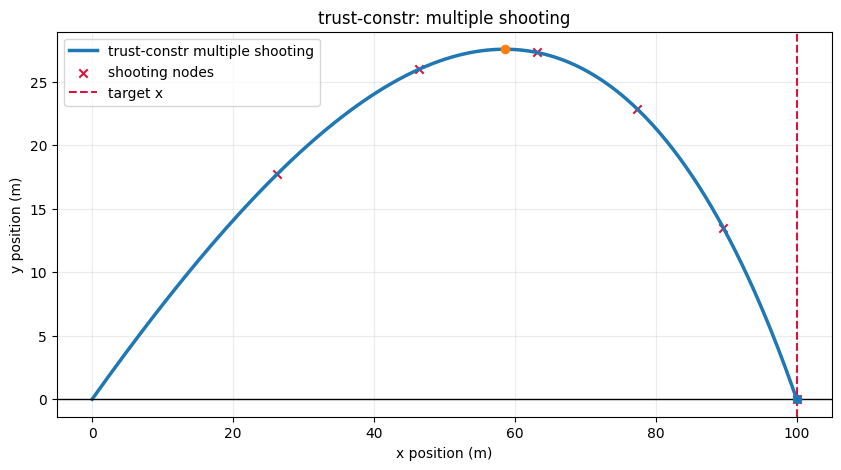

In [18]:
# Reuse what you already wrote above:
# - multiple_shooting_energy_objective(z)
# - multiple_shooting_defects_and_terminal(z)
# - multiple_shooting_initial_guess
# - multiple_shooting_bounds
# - unpack_multiple_shooting_z(z)
#
# The defect function returns many equality residuals, and trust-constr wants
# every residual to stay between lb and ub. Equality means lb = ub = 0.

# These are bounds on the decision variables themselves, not on the constraints.
# multiple_shooting_bounds is a list of (lower, upper) pairs, one pair per entry in z.
# trust-constr wants one Bounds object with two arrays: all lowers and all uppers.
# If a side is None, convert it to +/-inf to mean "unbounded" on that side.
multiple_trust_lb = [lo if lo is not None else -np.inf for lo, hi in multiple_shooting_bounds]
multiple_trust_ub = [hi if hi is not None else np.inf for lo, hi in multiple_shooting_bounds]
multiple_trust_bounds = Bounds(multiple_trust_lb, multiple_trust_ub)

# lb and ub bound every residual returned by multiple_shooting_defects_and_terminal.
# The residual vector contains segment defects plus terminal target errors.
# Setting lb=ub=0 makes every residual an equality constraint.
multiple_trust_defect_constraint = NonlinearConstraint(
    fun=multiple_shooting_defects_and_terminal,
    lb=0.0,
    ub=0.0,
)

# Teaching notes:
# - multiple shooting usually gives the optimizer more variables.
# - The extra variables are tied together by defect constraints.
# - trust-constr can be more informative for constrained problems, especially
#   when you later add analytic jacobians or sparsity.
# - Start by reusing your SLSQP functions exactly; only change the optimizer API.
#
# Your task:
# 1. Make sure the SLSQP multiple-shooting cell works first.
# 2. Uncomment the block below.
# 3. Compare the residual norm with the SLSQP residual norm.

result_ms_trust = minimize(
    multiple_shooting_energy_objective,
    multiple_shooting_initial_guess,
    method="trust-constr",
    bounds=multiple_trust_bounds,
    constraints=[multiple_trust_defect_constraint],
    options={"maxiter": 200, "verbose": 2},
)

best_control_ms_trust, best_final_time_ms_trust, best_nodes_ms_trust = unpack_multiple_shooting_z(result_ms_trust.x)
print(result_ms_trust)
print("best control:", best_control_ms_trust)
print("best final time:", best_final_time_ms_trust)
print("initial energy:", multiple_shooting_energy_objective(result_ms_trust.x))
print("constraint residual norm:", np.linalg.norm(multiple_shooting_defects_and_terminal(result_ms_trust.x)))

fig, ax = plt.subplots(figsize=(10, 5))
plot_shot(best_control_ms_trust, ax=ax, label="trust-constr multiple shooting")
ax.scatter(best_nodes_ms_trust[:, 0], best_nodes_ms_trust[:, 1], marker="x", color="crimson", label="shooting nodes")
ax.axvline(target_x, color="crimson", linestyle="--", label="target x")
ax.axhline(0, color="black", linewidth=1)
ax.set_title("trust-constr: multiple shooting")
ax.set_xlabel("x position (m)")
ax.set_ylabel("y position (m)")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()
